In [1]:
from mylib.statistic_test import *
from zfish._io import import16chFlt
from zfish.local_path import *
import os

import numpy as np
import matplotlib.pyplot as plt
from zfish.utils import *

code_id = "5007 - Spatial Preference"
loc = os.path.join(figpath, code_id)
os.makedirs(loc, exist_ok=True)

landmark_pos = [
    (0, 1/18), # Starting Point box
    (1/9, 2/9), # Leaves
    (5/18, 7/18), # Stars
    (4/9, 5/9), # Polygons
    (11/18, 13/18), # Triangles
    (14/18, 15/18), # Gravel
    (16/18, 17/18) # Teeth of Predators
]

d:\Software\Anaconda3\envs\maze\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def process(res: SwimDataDict):
    init_mask = filt_init_mask(res['behav_pos_y'], res['behav_time'])
    for k in res.keys():
        res[k] = res[k][init_mask]
        
    # Smooth both channel:
    for k in ['fltCh0', 'fltCh1']:
        res[k] = np.convolve(res[k], np.ones(600)/600, mode='same')
    
    # Compute speed:
    x = res['behav_pos_y'] + 50 * res['n_trials']
    t = res['behav_time']
    dx = np.diff(x)
    dt = np.diff(t)
    
    idx = np.append([0], np.where(dx/dt >= 0)[0])  # Threshold for movement, can be adjusted
    for k in res.keys():
        res[k] = res[k][idx]    
    
    dx = dx[idx[1:]]  # Adjust dx to match the length of idx
    dt = dt[idx[1:]]  # Adjust dt to match the length of idx
    
    speed = np.convolve(dx/dt, np.ones(600)/600, mode='same')
    speed = np.concatenate([[0], speed])  # Pad the first element to match the length of other arrays
    res['smooth_speed'] = speed
    

    
    # Downsample fro 6kHz to 30Hz:
    for k in res.keys():
        res[k] = res[k][::200]    
    
    for k in res.keys():
        res[k] = res[k][10:-10]
        
    return res

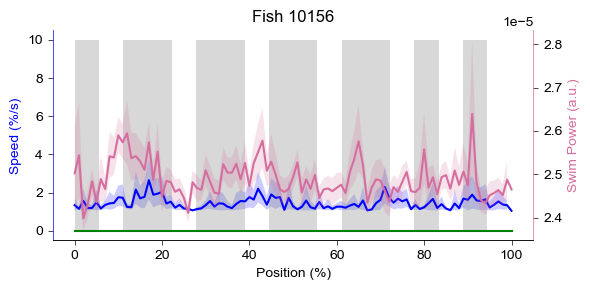

In [8]:
# file_dir = r"D:\EnData\Light-sheet\spatial preference vr1\10153\S2\res.16chFlt"
file_dir = r"D:\EnData\Light-sheet\10156\S2\res.16chFlt"
fish_id = 10156
res: SwimDataDict = import16chFlt(file_dir)
res = process(res)
res['behav_pos_y'] = (res['behav_pos_y'] // 0.5).astype(np.int32)
res['behav_pos_y_rand'] = np.roll(res['behav_pos_y'], np.random.randint(12000, len(res['behav_pos_y'])))

idx = np.where(res['n_trials'] <= 10)[0]
for k in res.keys():
    res[k] = res[k][idx]

if fish_id == 10141:
    res['mean_fltCh'] = res['fltCh1']
else:
    res['mean_fltCh'] = (res['fltCh0'] + res['fltCh1']) / 2
fig = plt.figure(figsize=(6, 3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
sns.lineplot(
    x='behav_pos_y', 
    y='smooth_speed',
    data=res,
    ax=ax,
    color="blue",
    err_kws={'edgecolor': None}
)
ax.spines['left'].set_color('blue')
sns.lineplot(
    x='behav_pos_y', 
    y='opto_states',
    data=res,
    color='green',
    ax=ax,
    err_kws={'edgecolor': None}
)
axt = Clear_Axes(ax.twinx(), close_spines=['top', 'left'], ifxticks=True, ifyticks=True)
sns.lineplot(
    x='behav_pos_y', 
    y='mean_fltCh',
    data=res,
    color=ChannelColors[0],
    ax=axt,
    err_kws={'edgecolor': None}
)

axt.spines['right'].set_color(ChannelColors[0])
axt.set_ylabel("Swim Power (a.u.)", color=ChannelColors[0])
for (start, end) in landmark_pos:
    ax.fill_betweenx([0, 10], start*100, end*100, color='gray', alpha=0.3, edgecolor=None)
ax.set_xlabel('Position (%)')
ax.set_ylabel('Speed (%/s)', color='blue')
ax.set_title(f"Fish {fish_id}")
plt.tight_layout()
plt.savefig(os.path.join(loc, f"{fish_id} [first 10 trials].svg"), dpi=300)
plt.show()

In [2]:
path = r"D:\EnData\Light-sheet\10156"

with open(os.path.join(path, "trace.pkl"), 'rb') as f:
    trace = pickle.load(f)

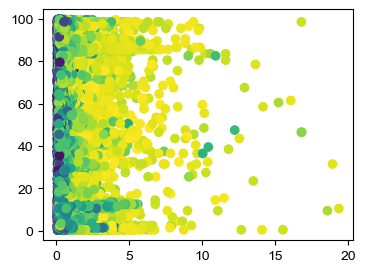

        D:\EnData\Light-sheet\10156\RateMap is already existed!
15066


  6%|▌         | 569/9216 [47:34<7:42:59,  3.21s/it] 

In [ ]:
def radar_visualization(
    x, y, 
    snr, 
    n_bin: int = 100, 
    cell_idx:np.ndarray = None, 
    meanImg=None,
    lenX:int=0,
    lenY:int=0,
    rois=None,
    fps: float = 2
):
    theta = x / n_bin  * 2 * np.pi
    radial = y
    
    # Compute CI per bin
    def compute_CI(x, y):
        top_boundary = np.zeros(n_bin)
        low_boundary = np.zeros(n_bin)
        means = np.zeros(n_bin)
        for i in range(n_bin):
            bin_values = y[x == i]
            if len(bin_values) > 0:
                mean = np.nanmean(bin_values)
                means[i] = mean
                sem = np.nanstd(bin_values) / np.sqrt(len(bin_values))
                top_boundary[i] = mean + sem
                low_boundary[i] = mean - sem
            else:
                top_boundary[i] = np.nan
                low_boundary[i] = np.nan

        x = np.arange(n_bin)/n_bin * 2 * np.pi
        y = means
        return x, y, low_boundary, top_boundary
    
    fig = plt.figure(figsize=(9, 6))
    gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 3])

    ax1 = fig.add_subplot(gs[0, 0])                    # row 1, col 1, normal 2D
    ax2 = fig.add_subplot(gs[0, 1])                    # row 1, col 2, normal 2D
    ax4 = fig.add_subplot(gs[1, 0])                    # row 2, col 1, normal 2D
    ax3 = fig.add_subplot(gs[1, 1], projection='polar')  # row 2, col 2, radar/polar
    for i in tqdm(cell_idx):
        ax1 = Clear_Axes(ax1, close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
        ax1.plot(np.arange(len(y[i]))/fps, y[i], color='k', linewidth=0.3)
        ax1.set_title(f"Cell {i} (SNR: {snr[i]:.2f})")
        ax1.set_xlabel('Time (s)')
        ax1.set_ylabel('Raw dF/F')
        
        # Tuning Curve ============================
        ax2 = Clear_Axes(ax2, close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
    
        sns.lineplot(x=x, y=y[i], ax=ax2, err_kws={'edgecolor': None}, linewidth=0.5)
        ylims = ax2.get_ylim()
        for (start, end) in landmark_pos:
            ax2.fill_betweenx(ylims, start*100, end*100, color=ChannelColors[0], alpha=0.1, edgecolor=None)      
        ax2.set_xlabel('Position (%)')  
        ax2.set_ylabel('Raw dF/F')
        ax2.set_xticks(np.linspace(0, 100, 6))
        
        ax4 = Clear_Axes(ax4)
        iplane = rois[i, 2]
    
        y_total, x_total = meanImg.shape
        x_nplane, y_nplane = int(x_total / lenX), int(y_total / lenY)
        xp, yp = iplane % x_nplane, iplane // x_nplane
        x_roi = int(rois[i, 0] - xp*lenX)
        y_roi = int(rois[i, 1] - yp*lenY)
        
        ax4.imshow(meanImg[yp*lenY:(yp+1)*lenY, xp*lenX:(xp+1)*lenX], cmap='gray')
        ax4.scatter(x_roi, y_roi, color='red', s=10, edgecolor=None)
        ax4.set_title(f"Plane {iplane}")
        
        # Radar plot ============================
        x0, y0, low_boundary, top_boundary = compute_CI(x, y[i])
        x0 = np.append(x0, x0[0])  # Close the loop
        y0 = np.append(y0, y0[0])  # Close the loop
        low_boundary = np.append(low_boundary, low_boundary[0])  # Close the loop
        top_boundary = np.append(top_boundary, top_boundary[0])  # Close the loop
        
        
        ax3.plot(np.arange(n_bin)/n_bin * 2 * np.pi, np.zeros(n_bin), color='red', linewidth=0.5)
        # Set the 4 background angular lines
        ax3.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2])
        ax3.set_xticklabels(["0%", "25%", "50%", "75%"])
        
        d_min, d_max = np.min(low_boundary), np.max(top_boundary)
        for (start, end) in landmark_pos:
            ax3.fill_betweenx([d_min, d_max], start*2*np.pi, end*2*np.pi, color=ChannelColors[0], alpha=0.1, edgecolor=None)
        ax3.plot(x0, y0, linewidth=0.5)
        ax3.fill_between(x=x0, y1=low_boundary, y2=top_boundary, color='blue', alpha=0.3, edgecolor=None)
        plt.savefig(os.path.join(save_dir, f"Cell {i}.png"), dpi=300)
        ax1.clear()
        ax2.clear()
        ax3.clear()
        ax4.clear()
    plt.show()

plt.figure(figsize=(4, 3))
plt.scatter(
    x=trace['tuning_params']['amplitude'], 
    y=trace['tuning_params']['center'], 
    c=trace['snr']
)
plt.show()

save_dir = os.path.join(path, "RateMap")
mkdir(save_dir)
x = trace['spike_nodes'][200:]
y = trace['RawTraces'][:, 200:]
idx = np.where(trace['tuning_params']['amplitude'] > 1)[0]
print(idx.shape[0])

n_bins = 100

radar_visualization(
    x, y, 
    snr=trace['snr'], 
    n_bin=trace['rate_map_all'].shape[1], 
    cell_idx=idx[5850:], 
    meanImg=trace['meanImg'],
    lenX=trace['lenX'],
    lenY=trace['lenY'],
    rois=trace['roi_coord'],
    fps=trace['fs']
)
""""""
print(np.max(trace['roi_coord'][:, 0]), np.max(trace['roi_coord'][:, 1]), trace['meanImg'].shape, trace['lenX'], trace['lenY'])

# Correlation Analysis

In [ ]:
idx = np.where(trace['snr'] >= 0.6)[0]
corr = np.corrcoef(trace['rate_map_all'][idx, :, 0])

In [ ]:
pos = np.where(idx==15120)[0][0] 
# 15029 and 15120 are anti-correlated
# 56036 is a great control
import numpy as np
from scipy.optimize import curve_fit

def two_gaussians(x, a1, mu1, sigma1, a2, mu2, sigma2):
    g1 = a1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2))
    g2 = a2 * np.exp(-(x - mu2)**2 / (2 * sigma2**2))
    return g1 + g2

p0 = [0.5, 0, 0.5, 0.5, 0.5, 0.5]
dist = np.histogram(corr[pos, :], bins=100, range=(-1, 1), density=True)[0]
bins = np.linspace(-1, 1, 101)
bins = (bins[:-1] + bins[1:]) / 2
popt, _ = curve_fit(two_gaussians, bins, dist, p0=p0)
x_fit = np.linspace(-1, 1, 1000)
y_fit = two_gaussians(x_fit, *popt)
print("Fitted parameters:", popt)

plt.hist(corr[pos, :], bins=100, range=(-1, 1), density=True)
plt.plot(x_fit, y_fit, color='red')
plt.show()
print(np.where(corr[pos, :] > 0.75)[0].shape)